In [4]:
import sys, os
import tkinter as tk
import time
from matplotlib import pyplot as plt
import cv2
import queue
import numpy as np
from tdmclient import ClientAsync, aw

# Compute absolute path to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), "."))
src_path = os.path.join(project_root, "src")

# Add src/ to sys.path
if src_path not in sys.path:
    print(f"Adding {src_path} to PYTHONPATH")
    sys.path.insert(0, src_path)

In [ ]:
from src.gui.init_vision_wizard import InitVisionWizard
from src.utils.camera_utils import find_available_camera
from src.computer_vision.camera_capture_thread import CameraCaptureThread
from src.computer_vision.computer_vision import ComputerVisionCore
from src.computer_vision.vision_params_manager import VisionParamsManager
from src.global_navigation.global_nav2 import GlobalNavigator
from src.computer_vision.vision import Vision
from src.pose_estimation.extended_kalman_filter import ExtendedKalmanFilter
from src.pose_estimation.differential_drive_system import DifferentialDriveSystem
#from src.local_navigation.navigation_control import *
from src.local_navigation.avoidancetest_andy import * 


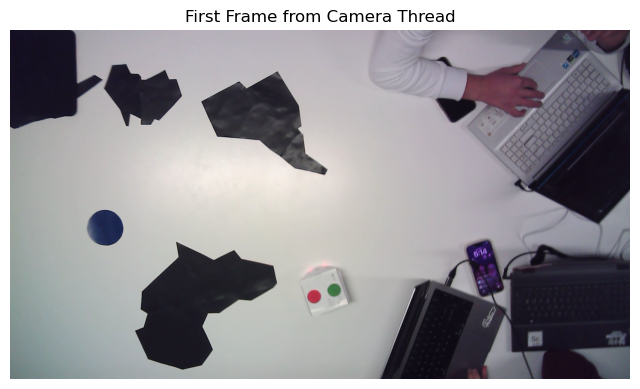

KeyboardInterrupt: 

In [7]:
# -------------------------
# Initialize Vision Wizard
# -------------------------

# Function to handle initialization on button click
def on_initialize(self):
    """Start computer vision initialization."""
    # 1. Capture ONE frame directly from the camera
    _, cap = find_available_camera()

    # Warm-up: try to grab a valid frame within 2 seconds
    start = time.time()
    frame = None
    while time.time() - start < 2.0:
        ok, f = cap.read()
        if ok and f is not None:
            # reject dark/black frames
            if f.mean() > 5:    # more robust than sum != 0
                frame = f
                break
        time.sleep(0.03)

    cap.release()

    if frame is None:
        raise RuntimeError("Failed to capture a valid frame from the camera.")

    # 3. Pass the captured FRAME to the wizard
    wizard = InitVisionWizard(self, frame)

    wizard.grab_set()           # modal window
    self.wait_window(wizard)    # wait for wizard to finish

    # 4. After the wizard is closed, you can access the results
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame from Camera Thread")
    plt.axis("off")
    plt.show()

# Launch a temporary Tkinter window to hold initialization button
root = tk.Tk()
root.title("Initialization window")

# Button to start initialization
btn = tk.Button(root, text="Initialize Vision", command=lambda: on_initialize(root))
btn.pack()

root.mainloop()

Waiting for first frame...
Received first frame, shape: (1080, 1920, 3)
Initial robot state: True (942, 815) None
Initial goal state: False None


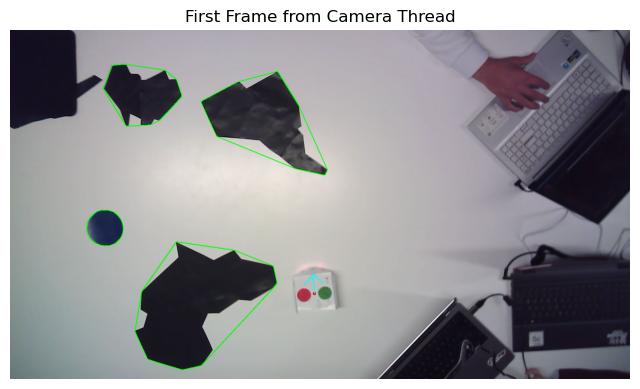

In [14]:
# -------------------------
# Capture first frame
# -------------------------

# 1. Create a queue for receiving camera frames + robot pose
data_queue = queue.Queue(maxsize=1)

# 2. Start the camera capture thread
camera_thread = CameraCaptureThread(queue=data_queue, device_index=0)
camera_thread.start()

# 3. Wait for the first data packet
print("Waiting for first frame...")
packet = None
while packet is None:
    try:
        packet = data_queue.get(timeout=1.0)
    except queue.Empty:
        print("Still waiting...")

frame = packet["frame"]
detections = packet["detections"]

robot = detections["robot"]
goal = detections["goal"]
obstacles = detections["obstacles"]

print("Received first frame, shape:", frame.shape)
print("Initial robot state:", robot["found"], robot.get("center", None), robot.get("orientation_deg", None))
print("Initial goal state:", goal["found"], goal.get("center", None))

camera_thread.stop()
camera_thread.join()

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("First Frame from Camera Thread")
plt.axis("off")
plt.show()

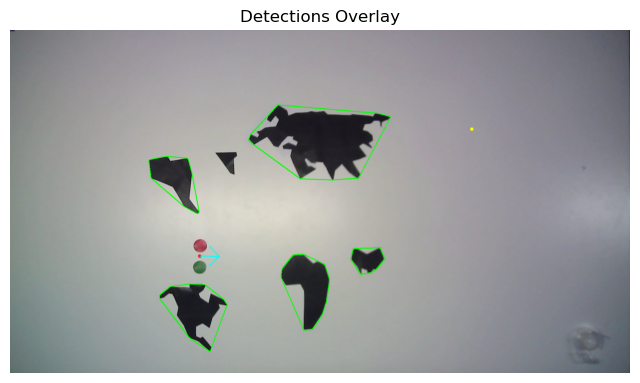

In [10]:
# --------------
# DEBUG cell
# --------------

params = VisionParamsManager()
params.load()

# Load an image/frame for path planning tests
frame = cv2.imread("vision_live_output_pour_mehdi.jpg")

overlay_frame = frame.copy()

# Vision wrapper handles smoothing internally
robot = ComputerVisionCore.detect_robot(frame, params.color_params)
goal = {"found": True, "center": (1400, 300)}  # Example goal data
obstacles = ComputerVisionCore.detect_obstacles(frame, params.color_params,params.canny_params, params.poly_params)

# Overlay static obstacles
for poly in obstacles:
    pts = np.array(poly.exterior.coords, np.int32)
    cv2.polylines(overlay_frame, [pts], True, (0, 255, 0), 2)

# Overlay goal
if goal and goal["found"] and goal["center"] is not None:
    cv2.circle(overlay_frame, goal["center"], 5, (0, 255, 255), -1)

# Overlay robot
if robot and robot["found"]:
    center = robot["center"]
    theta = robot["theta"]
    arrow_length = 60
    dx = int(arrow_length * np.cos(theta))
    dy = int(arrow_length * np.sin(theta))
    cv2.circle(overlay_frame, center, 5, (0, 0, 255), -1)
    cv2.arrowedLine(overlay_frame, center, (center[0]+dx, center[1]+dy), (255, 255, 0), 2, tipLength=0.7)

# Aggregate all detection data
detection_data = {
    "robot": robot,
    "goal": goal,
    "obstacles": obstacles
}

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(overlay_frame, cv2.COLOR_BGR2RGB))
plt.title("Detections Overlay")
plt.axis("off")
plt.show()

In [ ]:
# -----------------------------
# 1) Global path planning
# -----------------------------
path = None
if robot["found"] and goal["found"]:
    robot_center = robot["center"]   # (x_px, y_px)
    goal_center  = goal["center"]

    # Convert obstacles from Shapely Polygons to plain (x,y) lists
    obstacle_list = [list(p.exterior.coords)[:-1] for p in obstacles]

    # Compute global path in IMAGE PIXELS
    path, path_img = GlobalNavigator.plan_path(
        obstacles=obstacle_list,
        start=robot_center,
        goal=goal_center,
        robot_radius_px=ComputerVisionCore.mm_to_px(ComputerVisionCore.ROBOT_RADIUS_MM),
        img_width=frame.shape[1],
        img_height=frame.shape[0],
        debug_img=frame.copy()
    )

    # path is a list of (x_px, y_px) tuples
    print("Global path (px):", path)

    # ------------------------------------
    # 2) Convert path from px -> meters
    # ------------------------------------
    path_px = np.array(path, dtype=float)        # (N, 2) in pixels

    # Calibration: px <-> mm <-> m
    PX_PER_MM = ComputerVisionCore.mm_to_px(1.0)      # px for 1 mm
    MM_PER_PX = 1.0 / PX_PER_MM
    M_PER_PX  = MM_PER_PX / 1000.0                    # 1 px -> meters

    # Choose world origin at the initial robot position in the image
    GLOBAL_ORIGIN_PX = np.array(robot_center, dtype=float)

    def px_to_m(pt_px):
        """
        Convert (x_px, y_px) from image to (x_m, y_m) in world frame.
        World frame:
          - origin at GLOBAL_ORIGIN_PX
          - x axis to the right (same as image)
          - y axis downward  (same as image)
        """
        return (np.array(pt_px, dtype=float) - GLOBAL_ORIGIN_PX) * M_PER_PX

    # Path in meters (world frame)
    path_m = np.array([px_to_m(p) for p in path_px], dtype=float)

    # Densify in meters (e.g. every 2 cm)
    DENSE_PATH_M = densify_path(path_m, step=0.02)

    def center_px_to_pose_m(robot_center_px, theta):
        """
        Convert robot center from pixels to pose in meters:
            pose = [x_m, y_m, theta]
        where theta is the same angle you got from vision,
        measured in the same image/world coordinates.
        """
        dx_px, dy_px = np.array(robot_center_px, dtype=float) - GLOBAL_ORIGIN_PX
        x_m = dx_px * M_PER_PX
        y_m = dy_px * M_PER_PX
        return np.array([x_m, y_m, theta], dtype=float)

    # ------------------------------------
    # 3) visualization
    # ------------------------------------
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(path_img, cv2.COLOR_BGR2RGB))
    plt.title("Computed Global Path")
    plt.axis("off")
    plt.show()

else:
    raise RuntimeError("Robot or goal not found – cannot compute global path.")


In [26]:
# 1.6 EKF + Thymio client are created elsewhere, e.g.
# ekf = YourEKF(...)
# thymio = YourThymioClient(...)
lambda_ = 0.39735099337748336  # conversion factor
d = 93.5         # distance between wheels
# Default value for now
Q = np.diag([0.03, 0.03, 0.03])
R = np.diag([0.01, 0.01, 0.01])
dt = 0.1  # time step

system = DifferentialDriveSystem(dt, lambda_, d, Q, R)
    
# Initial state and covariance
mu0 = np.array([0, 0, 0])
Sigma0 = 1000 * np.eye(3)

ekf = ExtendedKalmanFilter(
    mu0, Sigma0,
    system
)

# To store estimates
x_est = []
P_est = []

x_est.append(mu0)

In [18]:
client = ClientAsync()
node = await client.wait_for_node()
await node.lock()
await node.wait_for_variables({"prox.horizontal"})

def motors(l_speed=0, r_speed=0):
    return {
        "motor.left.target": [int(l_speed)],
        "motor.right.target": [int(r_speed)],
    }



In [19]:
#await node.set_variables(motors(50,50))
await node.set_variables(motors(0,0))

In [ ]:
async def fsm():
    # Start the camera capture thread that will continuously push
    # (frame, detections) packets into data_queue
    camera_thread = CameraCaptureThread(queue=data_queue, device_index=0)
    camera_thread.start()   # NOTE: after the loop you should stop/join this thread

    print("Starting path following with obstacle avoidance...")
    for step in range(200):
        try:
            # Get the latest packet from the camera thread
            # Blocks up to 1 second, then raises queue.Empty
            packet = data_queue.get(timeout=1.0)
        except queue.Empty:
            print("Still waiting...")
            continue   # skip this iteration and try again
        
        # Unpack image + detections from the packet
        frame      = packet["frame"]
        detections = packet["detections"]

        robot_state = detections["robot"]
        goal_state  = detections["goal"]
        obstacles   = detections["obstacles"]

        # --- get sensors from Thymio ---
        # Read horizontal proximity sensors (front and rear)
        sensor_vals = list(node.v.prox.horizontal)
        
        # Read current wheel speeds (for EKF or logging)
        speed_left  = node.v.motor.left.speed
        speed_right = node.v.motor.right.speed
        u = np.array([speed_left, speed_right])
        # pose from ekf (if you want to use it):
        # pose, cov = ekf.predict(u)

        # --- build robot pose from vision (in meters) ---
        if robot_state["found"]:
            # Robot center in image pixels
            center_px = robot_state["center"]
            # Robot orientation (already in radians, same convention used in calibration)
            theta     = robot_state["theta"]
            # Convert center from px to meters in world frame (x, y, theta)
            pose      = center_px_to_pose_m(center_px, theta)
        else:
            # If robot is not detected, fall back to last estimated pose
            # or initial pose mu0 if no estimates yet
            pose = x_est[-1] if x_est else mu0

        # Store pose estimate history (for plotting / debugging later)
        x_est.append(pose)
        # P_est.append(cov)  # if you also track covariance from EKF
        print("Pose:", pose)

        # --- update local occupancy grid from sensors ---
        # This uses Thymio's prox readings, converts them to obstacle positions
        # in the robot frame, and inflates obstacles by robot radius
        grid.update_from_sensor_vals(sensor_vals)

        # --- compute virtual goal from local navigator ---
        # Uses:
        #   - current pose (m)
        #   - dense_path (m) precomputed from global planner
        #   - local occupancy grid (through 'navigator.grid')
        #   - sensor_vals to decide how much repulsion to apply
        virt_world, LA_world, F_att, F_rep = navigator.compute_virtual_goal(
            pose,
            DENSE_PATH_M,
            sensor_vals=sensor_vals
        )

        print("LQA (world):", LA_world)
        print("Virtual goal (world):", virt_world, "\n")

        # If navigator indicates no valid virtual goal (path finished / blocked),
        # stop the FSM loop
        if virt_world is None:
            break

        # --- controller: pose -> wheel motor commands ---
        # Go-to-goal PID + side/center heuristics based on sensor_vals
        # dt is your control timestep (e.g. 0.1 s)
        uL, uR, info = g2g.compute_motor_commands(
            pose,
            virt_world,
            sensor_vals=sensor_vals,
            dt=dt
        )

        # Send commands to Thymio motors
        await node.set_variables({
            "motor.left.target":  [uL],
            "motor.right.target": [uR],
        })

        # Small sleep to enforce control period dt
        await client.sleep(dt)

    # --- stop motors at the end of the loop ---
    await node.set_variables({
        "motor.left.target":  [0],
        "motor.right.target": [0],
    })

    # NOTE: you should also stop the camera thread here, e.g.:
    # camera_thread.stop()
    # camera_thread.join()

    # Unlock Thymio node (release control)
    await node.unlock()


In [28]:
await fsm()

Starting path following with obstacle avoidance...
Vision: x: 943 y: 814 theta: -1.648762960626439
Pose: [943.         814.          -1.64876296]
LQA (world): None
Virtual goal (world): None 



In [14]:
await node.set_variables(motors(0,0))

In [10]:
await node.unlock()

{'error_code': 2}